In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
main_df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv')


In [3]:
main_df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
main_df

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [5]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [6]:
main_df['Date'] = pd.to_datetime(main_df['Date'])

In [7]:
main_df.isna().sum()

Date    0
Temp    0
dtype: int64

In [8]:
main_df.nunique()

Date    3650
Temp     229
dtype: int64

In [9]:
main_df.groupby('Temp')['Date'].mean().sort_values()

Temp
24.8   1981-01-18 00:00:00
25.0   1981-01-27 12:00:00
21.9   1981-02-03 00:00:00
21.2   1981-02-22 00:00:00
3.4    1981-12-11 12:00:00
               ...        
19.6   1989-03-04 00:00:00
0.5    1989-06-28 00:00:00
1.8    1989-07-15 00:00:00
19.8   1989-07-29 12:00:00
21.6   1989-11-23 00:00:00
Name: Date, Length: 229, dtype: datetime64[ns]

In [10]:
main_df['Temp'].max()

np.float64(26.3)

In [11]:
main_df.loc[main_df["Temp"].idxmax(), ["Date", "Temp"]]


Date    1982-02-15 00:00:00
Temp                   26.3
Name: 410, dtype: object

In [12]:
main_df['Temp'].min()

np.float64(0.0)

In [13]:
main_df.loc[main_df["Temp"].idxmin(), ["Date", "Temp"]]

Date    1982-06-05 00:00:00
Temp                    0.0
Name: 520, dtype: object

In [14]:
main_df['Date'].sort_values(ascending=False)

3649   1990-12-31
3648   1990-12-30
3647   1990-12-29
3646   1990-12-28
3645   1990-12-27
          ...    
4      1981-01-05
3      1981-01-04
2      1981-01-03
1      1981-01-02
0      1981-01-01
Name: Date, Length: 3650, dtype: datetime64[ns]

In [15]:
pd.to_datetime("1990-12-31") - pd.to_datetime("1981-01-01")

Timedelta('3651 days 00:00:00')

In [16]:
3651/365

10.002739726027396

<Axes: xlabel='Date', ylabel='Temp'>

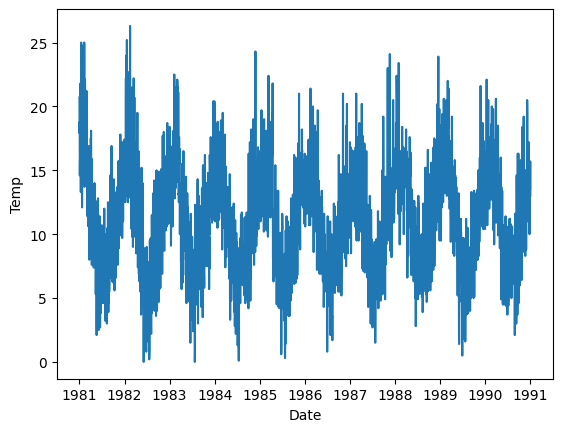

In [17]:
sns.lineplot(data=main_df ,x='Date',y='Temp')

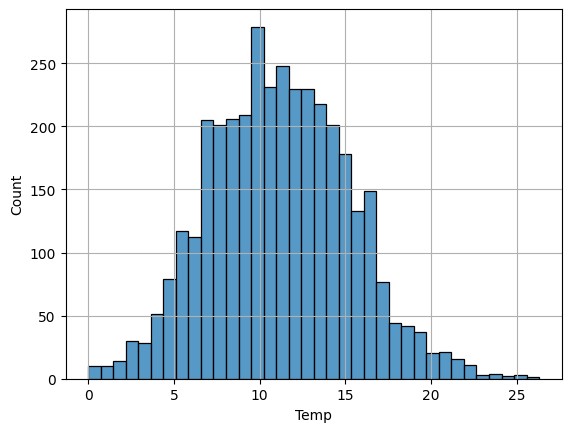

In [18]:
sns.histplot(data=main_df ,x='Temp')
plt.grid()


In [19]:
temp_df = main_df.copy()

In [20]:
temp_df

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


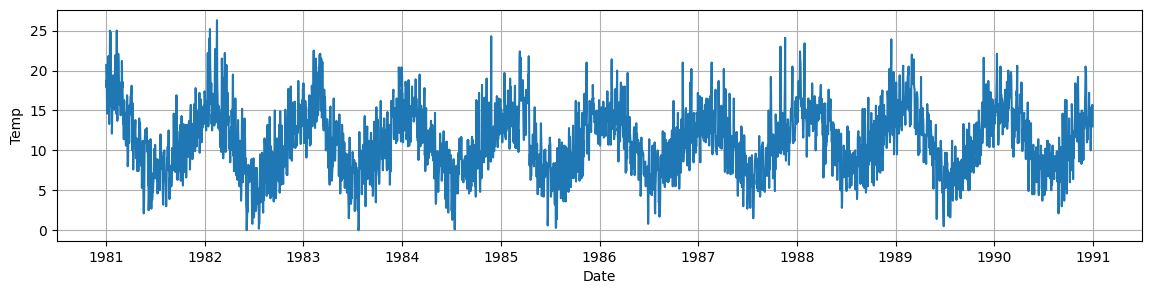

In [21]:
plt.figure(figsize=(14,3))
sns.lineplot(data=temp_df,x='Date',y='Temp')
plt.grid()

In [22]:
temp_df['daily_diffrence'] = temp_df['Temp'].diff()

In [23]:
temp_df['daily_diffrence']

0       NaN
1      -2.8
2       0.9
3      -4.2
4       1.2
       ... 
3645   -0.6
3646   -0.4
3647   -0.1
3648    2.2
3649   -2.7
Name: daily_diffrence, Length: 3650, dtype: float64

In [24]:
temp_df['daily_diffrence'] = temp_df['daily_diffrence'].fillna(temp_df['daily_diffrence'].mean())

<Axes: xlabel='Date', ylabel='daily_diffrence'>

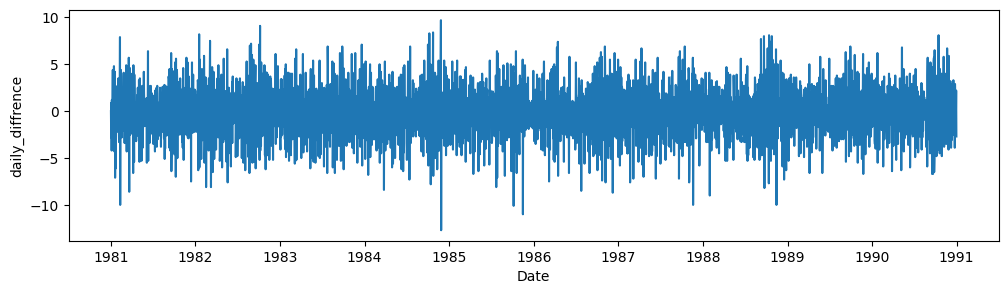

In [25]:
plt.figure(figsize=(12,3))
sns.lineplot(data=temp_df,y='daily_diffrence',x='Date')

Text(0.5, 1.0, 'looking for the possible outlier')

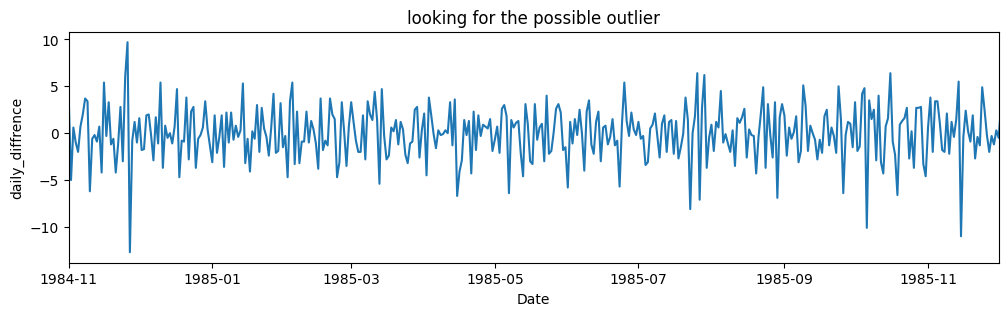

In [26]:
plt.figure(figsize=(12,3))
sns.lineplot(data=temp_df,y='daily_diffrence',x='Date')
plt.xlim(pd.to_datetime("1984-11-01"),pd.to_datetime("1985-12-01"))
plt.title('looking for the possible outlier')

Text(0.5, 1.0, 'looking for the possible outlier')

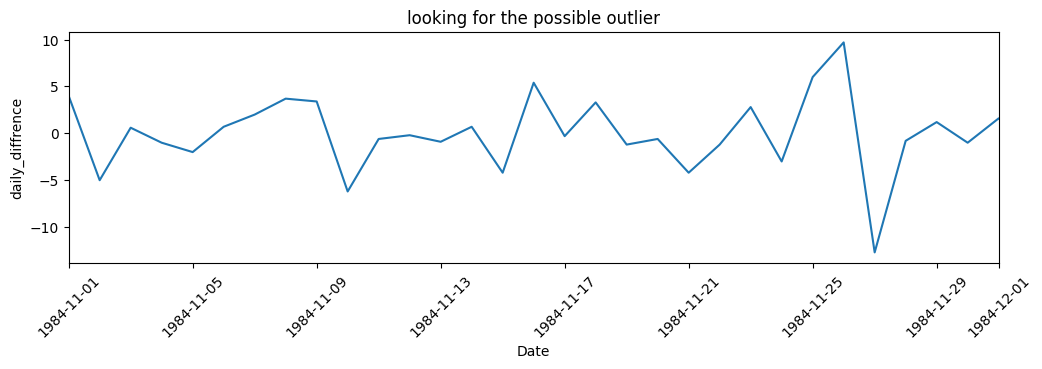

In [27]:
plt.figure(figsize=(12,3))
sns.lineplot(data=temp_df,y='daily_diffrence',x='Date')
plt.xlim(pd.to_datetime("1984-11-01"),pd.to_datetime("1984-12-01"))
plt.xticks(rotation=45)
plt.title('looking for the possible outlier')

Text(0.5, 1.0, 'looking for the possible outlier')

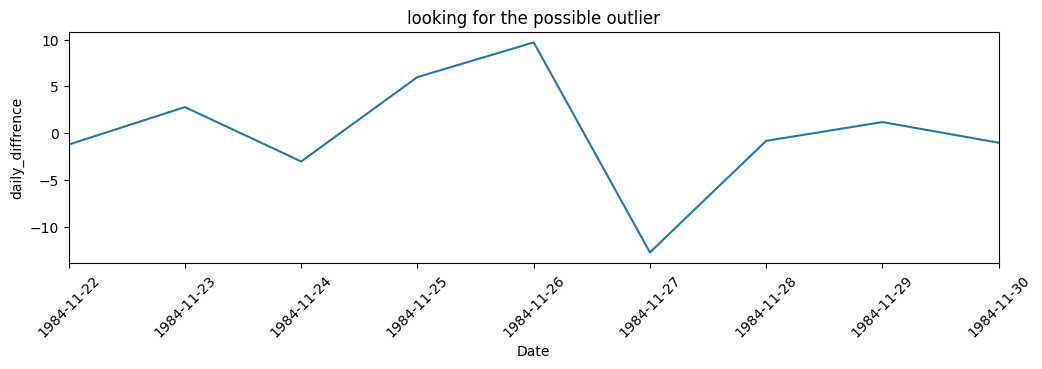

In [28]:
plt.figure(figsize=(12,3))
sns.lineplot(data=temp_df,y='daily_diffrence',x='Date')
plt.xlim(pd.to_datetime("1984-11-22"),pd.to_datetime("1984-11-30"))
plt.xticks(rotation=45)
plt.title('looking for the possible outlier')

In [29]:
# Her noktada, son 120 gözlemin ortalamasını al


In [30]:
# “Her gün için, son 200 günün ortalamasını hesapla.”
# “Bu veri uzun vadede yukarı mı gidiyor, aşağı mı?
# Rolling averages are used to smooth short-term fluctuations and highlight the underlying trend

In [31]:
temp_df['temp_rolling_15'] = temp_df['Temp'].rolling(15).mean()

In [32]:
temp_df['temp_rolling_15']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
3645    13.586667
3646    13.733333
3647    13.800000
3648    13.953333
3649    13.913333
Name: temp_rolling_15, Length: 3650, dtype: float64

In [33]:
temp_df

,Date,Temp,daily_diffrence,temp_rolling_15
0,1981-01-01,20.7,-0.00211,NaN
1,1981-01-02,17.9,-2.80000,NaN
2,1981-01-03,18.8,0.90000,NaN
3,1981-01-04,14.6,-4.20000,NaN
4,1981-01-05,15.8,1.20000,NaN
...,...,...,...,...
3645,1990-12-27,14.0,-0.60000,13.586667
3646,1990-12-28,13.6,-0.40000,13.733333
3647,1990-12-29,13.5,-0.10000,13.800000
3648,1990-12-30,15.7,2.20000,13.953333


In [34]:
from scipy.stats import zscore
# “Bu değer, ortalamadan kaç standart sapma uzakta?”

In [35]:
temp_df['z'] = zscore(temp_df['daily_diffrence'])
temp_df[temp_df['z'].abs() > 3]

,Date,Temp,daily_diffrence,temp_rolling_15,z
40,1981-02-10,15.0,-10.0,17.573333,-3.661125
79,1981-03-21,8.1,-8.6,13.000000,-3.148460
381,1982-01-17,24.0,8.2,15.946667,3.003529
644,1982-10-07,14.9,9.1,8.453333,3.333100
1179,1984-03-25,9.4,-8.4,13.473333,-3.075222
1375,1984-10-07,16.0,8.3,9.073333,3.040148
1391,1984-10-23,18.2,8.4,9.980000,3.076767
1425,1984-11-26,24.3,9.7,12.740000,3.552814
1426,1984-11-27,11.6,-12.7,12.713333,-4.649838
1738,1985-10-06,6.1,-10.1,9.120000,-3.697744


In [36]:
#The time series plot shows no unusual values, so there are no outliers in the data.

<Axes: xlabel='Date', ylabel='temp_rolling_15'>

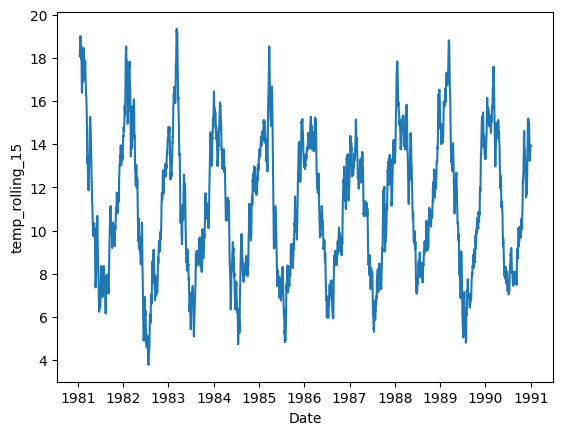

In [37]:
sns.lineplot(data=temp_df,x='Date',y='temp_rolling_15')

In [38]:
# acf grafigi dunku deger bugunu etkiliyo mu
from statsmodels.graphics.tsaplots import plot_acf

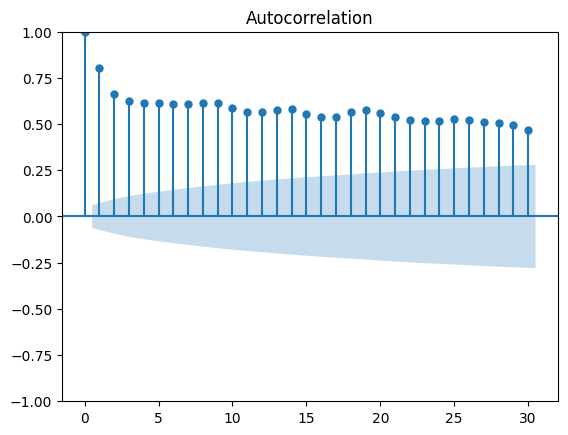

<Figure size 1400x300 with 0 Axes>

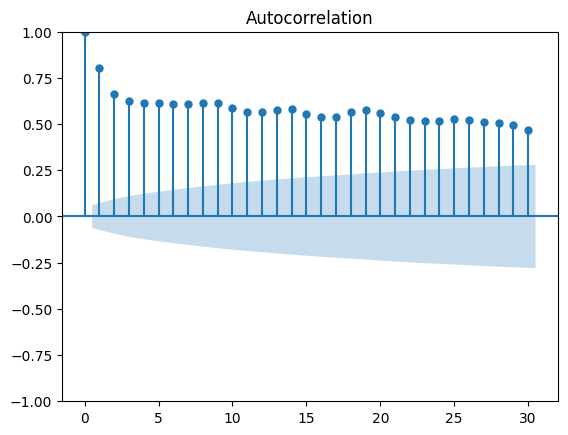

In [39]:
plt.figure(figsize=(14,3))
plot_acf(temp_df['Temp'][:1000])

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [41]:
decomposition = seasonal_decompose(temp_df['Temp'],period=15)

In [42]:
decomposition

In [43]:
#plt.figure(figsize=(14,3))
#sns.lineplot(x=temp_df.index[:1000],y=temp_df['Temp'][:1000]) # Temperature (Temp) değerlerinin ilk 1000 gözlemini çiziyor.
#sns.lineplot(decomposition.trend[:1000])
#sns.lineplot(decomposition.seasonal[:1000])
#plt.axhline(temp_df['Temp'][:1000].mean())
#plt.grid()

<Axes: xlabel='None', ylabel='Temp'>

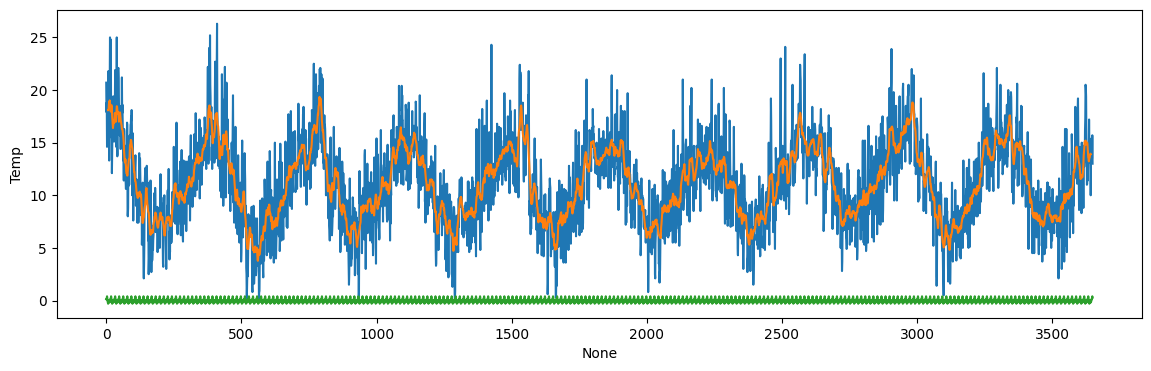

In [44]:
plt.figure(figsize=(14,4))
sns.lineplot(x=temp_df.index,y= temp_df['Temp'])
sns.lineplot(decomposition.trend)#Sadece genel hareket
sns.lineplot(decomposition.seasonal) #Bu noktada tekrar eden desen, veriyi ortalamadan ne kadar saptırıyor?”



<Axes: ylabel='resid'>

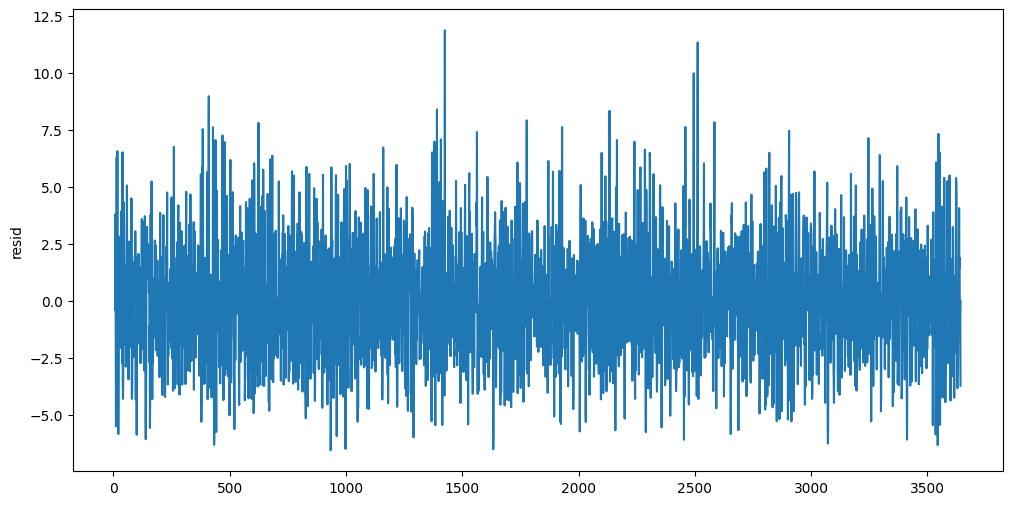

In [45]:
plt.figure(figsize=(12,6))
sns.lineplot(decomposition.resid)

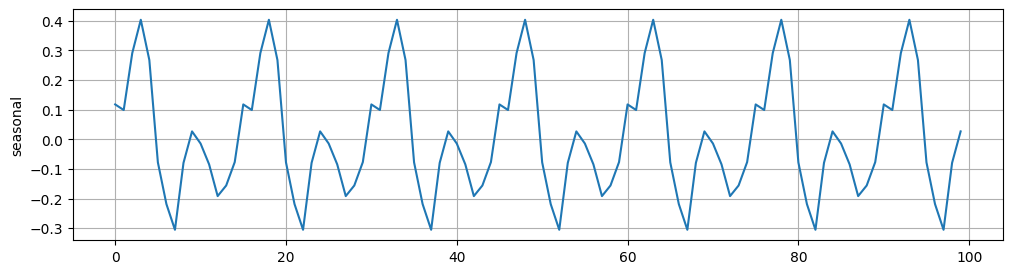

In [46]:
plt.figure(figsize=(12,3))
sns.lineplot(decomposition.seasonal[:100])
plt.grid()

<Axes: >

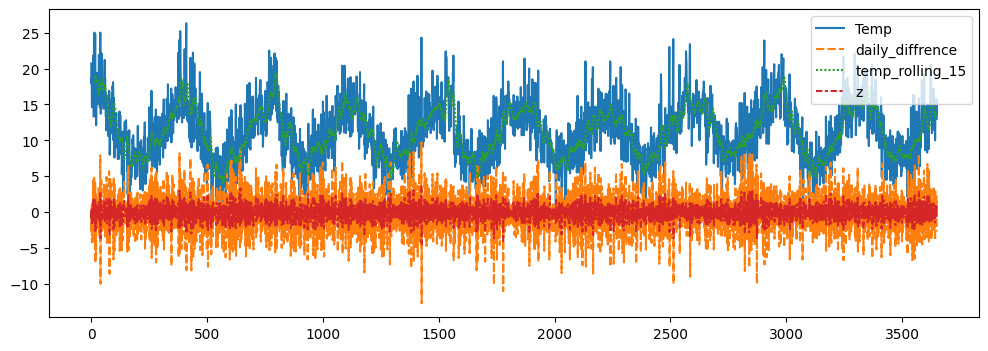

In [47]:
plt.figure(figsize=(12,4))
sns.lineplot(temp_df)

In [48]:
temp_df.columns

Index(['Date', 'Temp', 'daily_diffrence', 'temp_rolling_15', 'z'], dtype='object')

In [49]:
split_df =main_df.copy()

In [50]:
split_df

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


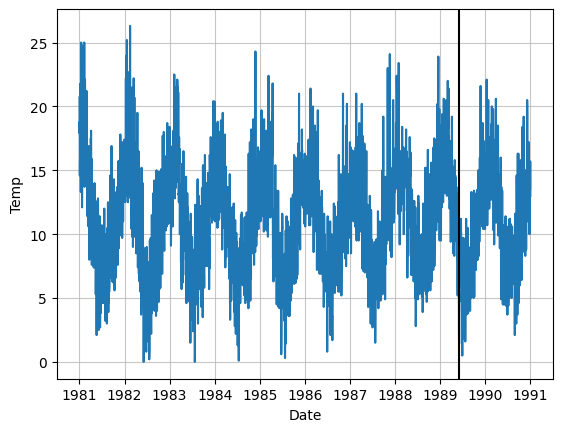

In [51]:
sns.lineplot(data=split_df,x='Date',y='Temp')
plt.axvline(pd.to_datetime('1989-06-01'),color='black')
plt.grid(alpha=0.7)

In [52]:
split_df = split_df.set_index(split_df['Date'].sort_values())

In [53]:
split_df

,Date,Temp
Date,,
1981-01-01,1981-01-01,20.7
1981-01-02,1981-01-02,17.9
1981-01-03,1981-01-03,18.8
1981-01-04,1981-01-04,14.6
1981-01-05,1981-01-05,15.8
...,...,...
1990-12-27,1990-12-27,14.0
1990-12-28,1990-12-28,13.6
1990-12-29,1990-12-29,13.5


In [54]:
split_df= split_df.drop(columns=['Date'])

In [55]:
split_df

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [56]:
cutoff_date =pd.to_datetime('1989-06-01')
training_data = split_df[split_df.index < cutoff_date]
testing_data = split_df[split_df.index >= cutoff_date]

In [57]:
training_data

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1989-05-27,10.2
1989-05-28,10.3
1989-05-29,12.1


In [58]:
training_data.isna().sum()

Temp    0
dtype: int64

In [59]:
training_data['Temp'].loc[training_data.idxmax()]

Date
1982-02-15    26.3
Name: Temp, dtype: float64

In [60]:
training_data.index[-1]

Timestamp('1989-05-31 00:00:00')

In [61]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3071 entries, 1981-01-01 to 1989-05-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3071 non-null   float64
dtypes: float64(1)
memory usage: 112.5 KB


In [62]:
training_data.describe()

,Temp
count,3071.000000
mean,11.252719
std,4.082876
min,0.000000
25%,8.400000
50%,11.100000
75%,14.000000
max,26.300000


In [63]:
testing_data

,Temp
Date,
1989-06-01,2.3
1989-06-02,1.4
1989-06-03,2.1
1989-06-04,6.6
1989-06-05,8.9
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [64]:
testing_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 579 entries, 1989-06-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    579 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


In [65]:
testing_data.isna().sum()

Temp    0
dtype: int64

In [66]:
testing_data['Temp'].loc[testing_data.idxmax()]

Date
1990-01-11    22.1
Name: Temp, dtype: float64

In [67]:
testing_data.index[-1]

Timestamp('1990-12-31 00:00:00')

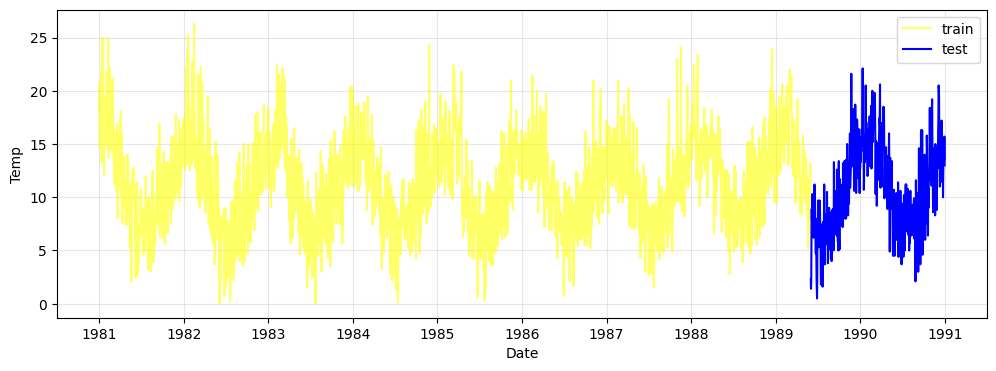

In [68]:
plt.figure(figsize=(12,4))

sns.lineplot(data=training_data, x=training_data.index, y='Temp', label='train', color='yellow',alpha=0.6)
sns.lineplot(data=testing_data,  x=testing_data.index,  y='Temp', label='test',  color='blue')

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [73]:
training_data = training_data.asfreq('D') # ARIMA’ya şunu diyorsun:
#Bu veri HER GÜN geliyor.

In [69]:
pip install stats

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [71]:
from statsmodels.tsa.arima.model import ARIMA

In [74]:
model = ARIMA(endog=training_data,order=(
                                         2,  # p the number of autoregression terms  p = kaç gün geriye bakıyorum
                                         1, # d the number of differencing terms d, “kaçtayım?” yerine “ne kadar değiştim?” diye sordurur.
                                         2)) # q the number of moving average terms)) q DÜN NE KADAR SAÇMALADIM
    

In [75]:
results = model.fit()

In [ ]:
arima_pred = results.get_forecast(steps=len(testing_data)).predicted_mean

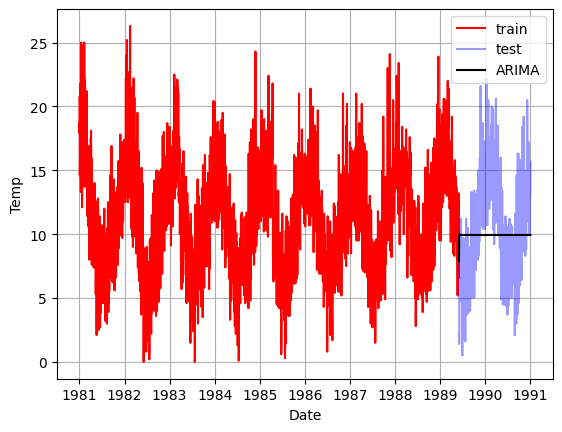

In [80]:
sns.lineplot(data=training_data, x=training_data.index, y='Temp', label='train', color='red')
sns.lineplot(data=testing_data,  x=testing_data.index,  y='Temp', label='test',  color='blue',alpha=(0.4))
sns.lineplot(x=testing_data.index,y=arima_pred,color='black',label='ARIMA')
plt.grid()

In [81]:
# we need to create a baseline to measure our predict

In [83]:
testing_data.isna().sum()

Temp    0
dtype: int64

In [84]:
# this baseline is doing to  looking for the previous value
#“shift(1) = bir önceki zamanı getirir”

In [85]:
baseline_y_Shift = testing_data.shift(3)

In [86]:
from sklearn.metrics import root_mean_squared_error,mean_squared_error,mean_absolute_error,r2_score

In [87]:
def model_evulation(actual_values,predict_values):
    print(f'root_mean_squared_error :{root_mean_squared_error(actual_values,predict_values)}')
    print(f'mean_squared_error :{mean_squared_error(actual_values,predict_values)}')
    print(f'mean_absolute_error :{mean_absolute_error(actual_values,predict_values)}')
    print(f'r2_score :{r2_score(actual_values,predict_values)}')

In [90]:
model_evulation(testing_data,arima_pred)

root_mean_squared_error :4.069836704325427
mean_squared_error :16.56357079987445
mean_absolute_error :3.3010123366691047
r2_score :-0.040775145409918556


In [93]:
baseline_y_Shift = baseline_y_Shift.fillna(baseline_y_Shift.iloc[4])
                                           

In [96]:
baseline_y_Shift.isna().sum()

Temp    0
dtype: int64

In [98]:
baseline_y_Shift.head(10)

,Temp
Date,
1989-06-01,1.4
1989-06-02,1.4
1989-06-03,1.4
1989-06-04,2.3
1989-06-05,1.4
1989-06-06,2.1
1989-06-07,6.6
1989-06-08,8.9
1989-06-09,7.8


In [99]:
model_evulation(testing_data,baseline_y_Shift)

root_mean_squared_error :3.456355063958561
mean_squared_error :11.946390328151988
mean_absolute_error :2.7219343696027636
r2_score :0.24934627435526924


In [102]:
#bunu (65,1) i =(65) 1d ye ceviriyo
baseline_1d = baseline_y_Shift.squeeze()

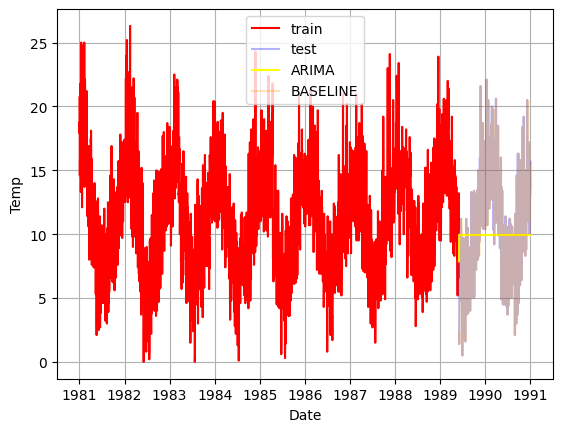

In [109]:
sns.lineplot(data=training_data, x=training_data.index, y='Temp', label='train', color='red')
sns.lineplot(data=testing_data,  x=testing_data.index,  y='Temp', label='test',  color='blue',alpha=(0.3))
sns.lineplot(x=testing_data.index,y=arima_pred,color='yellow',label='ARIMA')
sns.lineplot(x=testing_data.index,y=baseline_1d ,color='orange',label='BASELINE',alpha=(0.3))
plt.grid()

In [110]:
# ARIMA IS NOT GETTING A GOOD RESULT
# WE ARE MAKING A ExponentialSmoothing

In [135]:
training_data.isna().sum()

Temp    2
dtype: int64

In [136]:
training_data['Temp'] = training_data['Temp'].interpolate() # interpolate eksik gunleri komsularla doldur
testing_data['Temp']  = testing_data['Temp'].interpolate()

/tmp/ipykernel_14423/2205200268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing_data['Temp']  = testing_data['Temp'].interpolate()


In [137]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [138]:
ets_model = ExponentialSmoothing(
    training_data,
    seasonal='add',
    seasonal_periods=365
)

ets_result = ets_model.fit()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [139]:
ets_pred = ets_result.forecast(steps=len(testing_data))

In [140]:
ets_pred

1989-06-01     7.688749
1989-06-02     8.435946
1989-06-03     7.573762
1989-06-04     8.288725
1989-06-05     8.120235
                ...    
1990-12-27    15.268151
1990-12-28    16.486914
1990-12-29    16.794532
1990-12-30    17.876409
1990-12-31    15.668217
Freq: D, Length: 579, dtype: float64

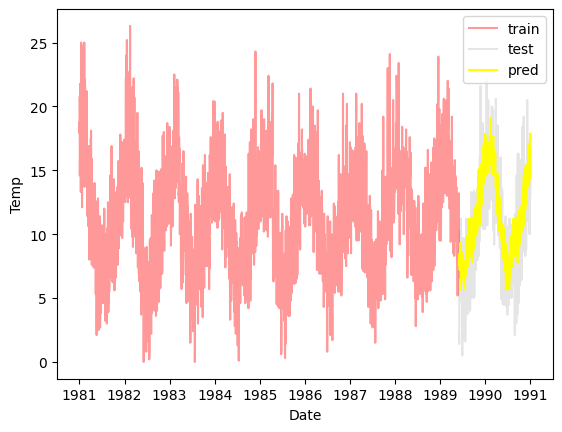

In [142]:
sns.lineplot(data=training_data, x=training_data.index, y='Temp', label='train', color='red',alpha=(0.4))
sns.lineplot(data=testing_data,  x=testing_data.index,  y='Temp', label='test',  color='black',alpha=(0.1))
sns.lineplot( x=testing_data.index,y=ets_pred,     label='pred',  color='yellow')
plt.legend()
plt.show()

In [143]:
model_evulation(testing_data,ets_pred)

root_mean_squared_error :2.7880601829181275
mean_squared_error :7.773279583573464
mean_absolute_error :2.2085859518163016
r2_score :0.5115644877149953


In [ ]:
#“After addressing missing dates and applying additive seasonality 
#with a yearly period, the ETS model significantly outperformed both ARIMA and a naïve baseline.”